# Explanation Notebook for ScenarioModel3
*Model Type:* **RandomForest**
*User:* UserRF (Expertise: Intermediate, Formats: [plainText, table, visual], Details: high, Purpose: general)
*Explanation Method:* FeatureImportance


## Training the RandomForest Model
We train a **RandomForest** model on the provided dataset.


In [1]:
import warnings; warnings.filterwarnings('ignore')
!pip install -q scikit-learn pandas matplotlib
import pandas as pd
from sklearn.model_selection import train_test_split
df = pd.read_csv(r"data/breast_cancer.csv")
y = df['target']
X = df.drop(columns=['target']).values
try:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
    print('[Info] Used stratified split to preserve class proportions in train/test.')
except Exception:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    print('[Info] Used non-stratified split (stratification not applicable).')
class Dummy: pass
data = Dummy(); data.feature_names = list(df.drop(columns=['target']).columns)
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=0)
print('[Info] Normalization disabled by training policy.')
model.fit(X_train, y_train)
print('Accuracy: RandomForest = ' + format(model.score(X_test, y_test), '.2f'))


[Info] Used stratified split to preserve class proportions in train/test.
[Info] Normalization disabled by training policy.
Accuracy: RandomForest = 0.95


## Explaining the model using FeatureImportance
Feature Importance ranks features by their overall influence on the model’s predictions.



[Feature Importance overview]
Feature importance is a global explanation: it ranks which features the model relies on most overall.

[Plain-text explanation]
This explanation summarizes the model's behaviour at a global level.
 - Worst Perimeter: importance=0.15296
 - Worst Concave Points: importance=0.12769
 - Worst Radius: importance=0.11327
 - Worst Area: importance=0.09206
 - Mean Concave Points: importance=0.09055
 - Mean Perimeter: importance=0.07467
 - Mean Concavity: importance=0.05289
 - Area Error: importance=0.04141
 - Mean Area: importance=0.04113
 - Worst Concavity: importance=0.03291

[Tabular explanation]
Columns: feature and global importance magnitude. Higher values indicate that the model relies more strongly on the feature overall.


,Feature,Importance
0,Worst Perimeter,0.152959
1,Worst Concave Points,0.127693
2,Worst Radius,0.113266
3,Worst Area,0.092056
4,Mean Concave Points,0.090547
5,Mean Perimeter,0.074674
6,Mean Concavity,0.052885
7,Area Error,0.041413
8,Mean Area,0.041133
9,Worst Concavity,0.032908



[Visual explanation]
How to read the plot: this is a global ranking of model reliance on features.
Use it to identify dominant features and compare the relative gap between the most and least influential ones shown.


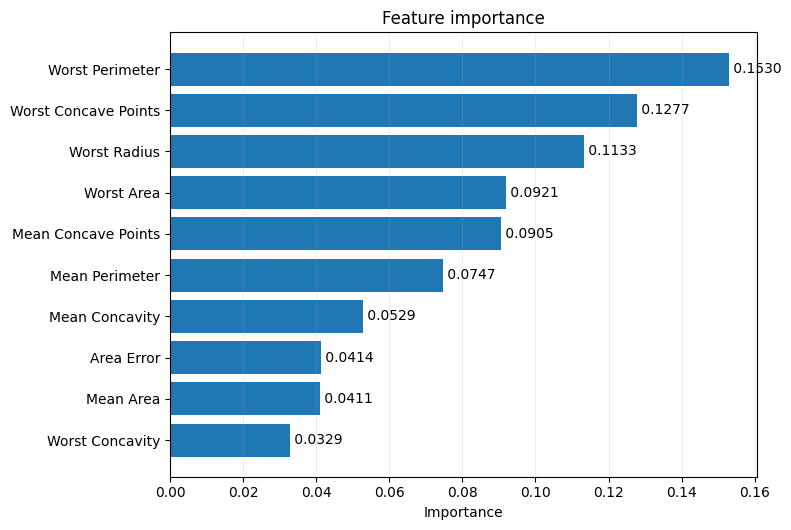

In [2]:
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt

def _get_feature_names():
    try:
        names = list(getattr(data, 'feature_names', []))
        if names and len(names) == X_train.shape[1]:
            return names
    except Exception:
        pass
    if 'df' in globals():
        cols = [c for c in df.columns if c.lower() not in ('label','target','y')]
        if len(cols) == X_train.shape[1]:
            return cols
    return [f'f{j}' for j in range(X_train.shape[1])]

RAW_NAMES = _get_feature_names()
def _humanize(name):
    s = name.replace('_',' ').strip()
    s = re.sub(r'(?<!^)(?=[A-Z])',' ', s)
    s = re.sub(r'\s+',' ', s).strip()
    return ' '.join([w.upper() if w.lower() in {'svm','pdp','ice','api','url'} else w.capitalize() for w in s.split(' ')])
HUMAN = [_humanize(n) for n in RAW_NAMES]

max_display = 10
table_rows = 14
curve_resolution = 40
ice_instances = 20
metric_digits = 6
figure_height = 5.4
line_width = 2.6
pdp_sample_rows = 10
ice_detailed_instances = 5
sampled_curve_points = 10
print('\n[Feature Importance overview]')
print('Feature importance is a global explanation: it ranks which features the model relies on most overall.')
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
elif hasattr(model, 'coef_'):
    coef = model.coef_
    importances = np.abs(coef[0]) if getattr(coef, 'ndim', 1) > 1 else np.abs(coef)
else:
    from sklearn.inspection import permutation_importance
    result = permutation_importance(model, X_test, y_test, n_repeats=5, random_state=0)
    importances = result.importances_mean
pairs = sorted(list(zip(HUMAN, importances)), key=lambda x: abs(float(x[1])), reverse=True)[:max_display]
df_fi = pd.DataFrame({'Feature':[p[0] for p in pairs], 'Importance':[abs(float(p[1])) for p in pairs]})
print('\n[Plain-text explanation]')
print("This explanation summarizes the model's behaviour at a global level.")
for _, r in df_fi.iterrows():
    print(' - ' + str(r['Feature']) + ': importance=' + format(r['Importance'], '.5f'))
print('\n[Tabular explanation]')
print('Columns: feature and global importance magnitude. Higher values indicate that the model relies more strongly on the feature overall.')
display(df_fi.head(table_rows))
print('\n[Visual explanation]')
print('How to read the plot: this is a global ranking of model reliance on features.')
print('Use it to identify dominant features and compare the relative gap between the most and least influential ones shown.')
plot_df = df_fi.sort_values('Importance')
plt.figure(figsize=(8, figure_height))
plt.barh(plot_df['Feature'], plot_df['Importance'])
plt.title('Feature importance')
plt.xlabel('Importance')
plt.grid(axis='x', alpha=0.2)
for idx, val in enumerate(plot_df['Importance']):
    plt.text(val, idx, ' ' + format(val, '.4f'), va='center')
plt.tight_layout(); plt.show()
